# Entrenamiento de modelo de predicción de categoría


## Importación de librerias necesarias


In [1]:
%load_ext IPython.extensions.autoreload
%autoreload 2


In [2]:
import os
from pathlib import Path
import sys

def find_src_folder(current_path: Path, folder_name: str = 'src') -> Path:
    search_directories = [current_path] + list(current_path.parents)
    for parent in search_directories:
        if parent.name == folder_name:
            return parent.parent
    return current_path

src_path = find_src_folder(Path.cwd(), 'src')
sys.path.append(str(src_path))

print(f"JAVA_HOME: {os.environ.get('JAVA_HOME')}")
print(f"TFHUB_CACHE_DIR: {os.environ.get('TFHUB_CACHE_DIR')}")


JAVA_HOME: /usr/lib/jvm/java-11-openjdk-amd64
TFHUB_CACHE_DIR: /mnt/d/Maestría/Amazon Reviews Code/tf_cache


In [3]:
import numpy as np
import pandas as pd
import sys
import os
import shutil
import tensorflow as tf
import tensorflow_io as tfio
from pyspark.sql import functions as F, types as T, DataFrame
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from pyspark.ml.functions import array_to_vector, vector_to_array
from pyspark.ml.feature import VectorAssembler


2025-10-19 20:51:39.867412: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-10-19 20:51:39.879592: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-10-19 20:51:39.883098: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1452] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-10-19 20:51:39.892296: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-10-19 20:51:41.532779: W tensorflow/compiler/tf2

In [4]:
print(f"Python executable: {sys.executable}")
print(f"Python version: {sys.version}")
print(f"TensorFlow version: {tf.__version__}")
print(f"CUDA built: {tf.test.is_built_with_cuda()}")

gpus = tf.config.list_physical_devices('GPU')
print(f"GPU devices: {gpus}")

if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print("GPU memory growth enabled")
    except RuntimeError as e:
        print(f"GPU memory growth error: {e}")

if gpus:
    with tf.device('/GPU:0'):
        a = tf.constant([[1.0, 2.0], [3.0, 4.0]])
        b = tf.constant([[2.0, 0.0], [0.0, 2.0]])
        c = tf.matmul(a, b)
        print(f"GPU test result: {c.numpy()}")
        print("✓ GPU is working!")
else:
    print("❌ No GPU detected")


Python executable: /mnt/d/Maestría/Amazon Reviews Code/.venv-linux/bin/python
Python version: 3.11.13 (main, Jun  4 2025, 08:57:30) [GCC 13.3.0]
TensorFlow version: 2.17.1
CUDA built: True
GPU devices: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
GPU memory growth enabled
GPU test result: [[2. 4.]
 [6. 8.]]
✓ GPU is working!


I0000 00:00:1760925106.105317  390832 cuda_executor.cc:1015] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
I0000 00:00:1760925106.151809  390832 cuda_executor.cc:1015] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
I0000 00:00:1760925106.152051  390832 cuda_executor.cc:1015] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
I0000 00:00:1760925106.153581  390832 cuda_executor.cc:1015] successful NUMA node read from SysFS ha

In [5]:
from src.utils.spark import SparkUtils, METASTORE_PATH
spark_utils = SparkUtils('predict_category_model')
spark = spark_utils.spark


:: loading settings :: url = jar:file:/mnt/d/Maestr%c3%ada/Amazon%20Reviews%20Code/.venv-linux/lib/python3.11/site-packages/pyspark/jars/ivy-2.5.1.jar!/org/apache/ivy/core/settings/ivysettings.xml


Ivy Default Cache set to: /home/edgar/.ivy2/cache
The jars for the packages stored in: /home/edgar/.ivy2/jars
io.delta#delta-spark_2.12 added as a dependency
:: resolving dependencies :: org.apache.spark#spark-submit-parent-6685351a-0bef-4e62-8f5b-c4673501801d;1.0
	confs: [default]
	found io.delta#delta-spark_2.12;3.0.0 in central
	found io.delta#delta-storage;3.0.0 in central
	found org.antlr#antlr4-runtime;4.9.3 in central
:: resolution report :: resolve 98ms :: artifacts dl 4ms
	:: modules in use:
	io.delta#delta-spark_2.12;3.0.0 from central in [default]
	io.delta#delta-storage;3.0.0 from central in [default]
	org.antlr#antlr4-runtime;4.9.3 from central in [default]
	---------------------------------------------------------------------
	|                  |            modules            ||   artifacts   |
	|       conf       | number| search|dwnlded|evicted|| number|dwnlded|
	---------------------------------------------------------------------
	|      default     |   3   |   0   |

## Cargar datos fuente de entrenamiento


In [6]:
GOLD_ENCODING = 'gold.encoding'
GOLD_PREMODELING = 'gold.premodeling'
GOLD_SCHEMA_CLUSTER = 'gold.cluster'
SCHEMA = 'silver.preprocess'


In [7]:
REGENERATE_MODEL = False


In [8]:
src_dir_category_prediction = f"{METASTORE_PATH}/warehouse/gold.premodeling/final_training_data_category_prediction"
dst_dir_category_prediction = f"{METASTORE_PATH}/warehouse/gold.premodeling/dataset_score_model_category_prediction"
dst_path_category_prediction = os.path.join(dst_dir_category_prediction, "dataset_training.parquet")


In [9]:
categories = spark.read.parquet(src_dir_category_prediction).schema.names
categories = [bytes(c, 'utf-8') for c in categories if c.startswith("main_category_")]

In [10]:
from src.utils.models import CategoryPredictionModel


In [11]:
category_prediction_model = CategoryPredictionModel(
    'category_prediction_model', METASTORE_PATH, tracking_uri="file:///mnt/d/Maestría/Amazon Reviews Code/.mlflow",
    num_classes=len(categories)
)


In [12]:
category_prediction_model.prepare_data(
    spark, src_dir_category_prediction, dst_dir_category_prediction, dst_path_category_prediction, target_columns=categories, shuffle_buffer_size = -1,
    train_ratio=0.8, val_ratio=0.1
)


2025-10-19 20:51:59.185150: I tensorflow_io/core/kernels/cpu_check.cc:128] Your CPU supports instructions that this TensorFlow IO binary was not compiled to use: SSE3 SSE4.1 SSE4.2 AVX AVX2 FMA


## Crear modelo de predicción


In [13]:
category_prediction_model.create_model()


<Sequential name=sequential, built=True>

In [14]:
category_prediction_model.model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 1024)           │       525,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 512)            │       524,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 9)              │            81 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,312,937 (5.01 MB)

 Trainable params: 1,312,937 (5.01 MB)

 Non-trainable params: 0 (0.00 B)

In [15]:
if True:
    history_model_category_prediction = category_prediction_model.train(epochs=20)


Epoch 1/20


I0000 00:00:1760925138.147666  391123 service.cc:146] XLA service 0x77a9f0014970 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1760925138.147686  391123 service.cc:154]   StreamExecutor device (0): NVIDIA GeForce RTX 3050, Compute Capability 8.6
2025-10-19 20:52:18.200477: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:268] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2025-10-19 20:52:18.524214: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:531] Loaded cuDNN version 8907
2025-10-19 20:52:21.278973: I external/local_xla/xla/stream_executor/cuda/cuda_asm_compiler.cc:393] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_3033', 20 bytes spill stores, 20 bytes spill loads

2025-10-19 20:52:22.016719: I external/local_xla/xla/stream_executor/cuda/cuda_asm_compiler.cc:393] ptxas warning : Registers are spilled to local memory in functi

      8/Unknown 14s 24ms/step - accuracy: 0.1434 - loss: 2.1983

I0000 00:00:1760925146.081219  391123 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


     56/Unknown 15s 28ms/step - accuracy: 0.0902 - loss: 2.2000

...

2025-10-19 20:53:27.069099: I tensorflow/core/framework/local_rendezvous.cc:423] Local rendezvous recv item cancelled. Key hash: 9846127464398976155
2025-10-19 20:53:27.069138: I tensorflow/core/framework/local_rendezvous.cc:423] Local rendezvous recv item cancelled. Key hash: 2147214048023787232


55/57 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.2735 - loss: 2.1509
Epoch 7: ReduceLROnPlateau reducing learning rate to 0.0001250000059371814.

Epoch 7: val_loss did not improve from 2.20965
57/57 ━━━━━━━━━━━━━━━━━━━━ 8s 106ms/step - accuracy: 0.1500 - loss: 2.1761 - val_accuracy: 0.0078 - val_loss: 2.2293 - learning_rate: 2.5000e-04
Epoch 8/20


2025-10-19 20:53:35.237156: I tensorflow/core/framework/local_rendezvous.cc:423] Local rendezvous recv item cancelled. Key hash: 9846127464398976155
2025-10-19 20:53:35.237195: I tensorflow/core/framework/local_rendezvous.cc:423] Local rendezvous recv item cancelled. Key hash: 2147214048023787232


55/57 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.2569 - loss: 2.1403
Epoch 8: val_loss did not improve from 2.20965
57/57 ━━━━━━━━━━━━━━━━━━━━ 8s 105ms/step - accuracy: 0.1631 - loss: 2.1611 - val_accuracy: 0.0156 - val_loss: 2.2372 - learning_rate: 1.2500e-04
Epoch 8: early stopping
Restoring model weights from the end of the best epoch: 1.


2025-10-19 20:53:43.395055: I tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
	 [[{{node IteratorGetNext}}]]
	 [[IteratorGetNext/_2]]
2025-10-19 20:53:43.395082: I tensorflow/core/framework/local_rendezvous.cc:423] Local rendezvous recv item cancelled. Key hash: 9846127464398976155
2025-10-19 20:53:43.395093: I tensorflow/core/framework/local_rendezvous.cc:423] Local rendezvous recv item cancelled. Key hash: 2147214048023787232


2025/10/19 20:53:44 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2025/10/19 20:53:44 WARNING mlflow.tensorflow: You are saving a TensorFlow Core model or Keras model without a signature. Inference with mlflow.pyfunc.spark_udf() will not work unless the model's pyfunc representation accepts pandas DataFrames as inference inputs.
2025/10/19 20:53:57 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


8081a0fc2a804d488a6927b3e5241620
Plot saved to /mnt/d/Maestría/Amazon Reviews Code/data/warehouse/gold.premodeling/training_history_category_prediction_model.png


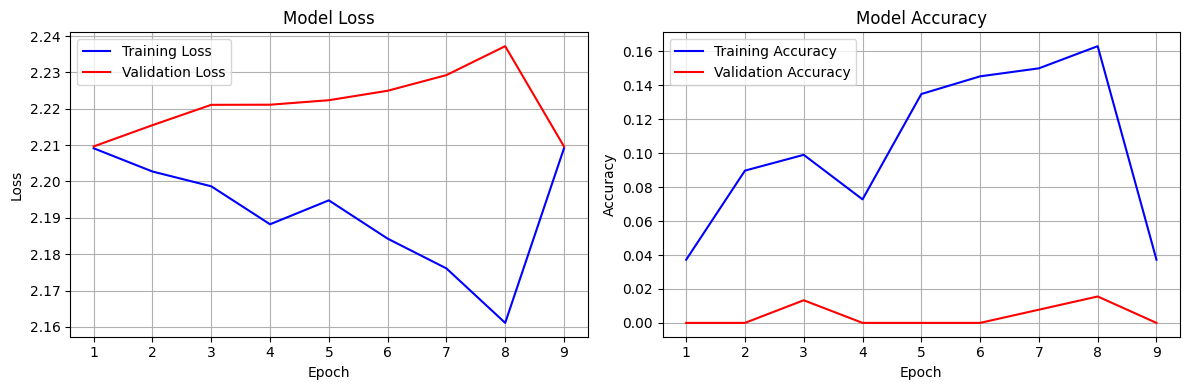

In [16]:
if True:
    for name, model in [
        ("category_prediction_model", category_prediction_model)
    ]:

        tags = {
            "model_type": "neural_network",
            "task": "rating_prediction",
            "dataset": "amazon_reviews",
            "variant": name
        }
 
        exp = model.log_training_history(
            run_name=f"{name}_{model.input_shape}features",
            tags=tags
        )

        print(exp)

        _ = model.plot_training_history(
            save_path=f"{METASTORE_PATH}/warehouse/gold.premodeling/training_history_{name}.png"
        )


## Cargar modelo


In [17]:
from src.utils.models import CategoryPredictionModel
categories = spark.read.parquet(src_dir_category_prediction).schema.names
categories = [bytes(c, 'utf-8') for c in categories if c.startswith("main_category_")]

category_prediction_model = CategoryPredictionModel('category_prediction_model', METASTORE_PATH, num_classes=len(categories), tracking_uri="file:///mnt/d/Maestría/Amazon Reviews Code/.mlflow")
category_prediction_model.load_latest_model()


/mnt/d/Maestría/Amazon Reviews Code/.venv-linux/lib/python3.11/site-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'rmsprop', because it has 28 variables whereas the saved optimizer has 54 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


In [18]:
category_prediction_model.list_available_models()



Available Model Versions (filtered by: category_prediction_model)

1. Run ID: 8081a0fc2a804d488a6927b3e5241620
   Run Name: category_prediction_model_512features
   Model Name: 
   Status: FINISHED
   Start Time: 2025-10-20 01:53:44.418000+00:00
   End Time: 2025-10-20 01:53:57.719000+00:00
   Metrics: Loss: 2.1611, Val Loss: 2.2372, Accuracy: 0.1631, Val Accuracy: 0.0156

2. Run ID: 499efee1e29e49d4a51d9826c7d8c702
   Run Name: category_prediction_model_512features
   Model Name: 
   Status: FINISHED
   Start Time: 2025-10-20 01:39:53.774000+00:00
   End Time: 2025-10-20 01:40:07.014000+00:00
   Metrics: Loss: 2.1342, Val Loss: 2.2229, Accuracy: 0.1833, Val Accuracy: 0.0300

3. Run ID: 44a6cacf12094e2f88522075e9670dd0
   Run Name: category_prediction_model_512features
   Model Name: 
   Status: FINISHED
   Start Time: 2025-10-20 01:28:10.860000+00:00
   End Time: 2025-10-20 01:28:25.288000+00:00
   Metrics: Loss: 2.1358, Val Loss: 2.2054, Accuracy: 0.1633, Val Accuracy: 0.1722

4. Ru